**Newton's cooling law**

Newton's Law of Cooling is governed by the differential equation:
$$ \frac{du}{dt} = - k (u-T).$$
The exact solution of Newton's Law of Cooling is

$$u(t)
=T+(u_0 - T) e^{-k⋅t}
$$

Let's generate 10 data points from the exact solution of Newton's Law of Cooling with the specified parameters

T=30 (ambient temperature)
u_0 =90 (initial temperature)
k=0.5 (cooling constant)

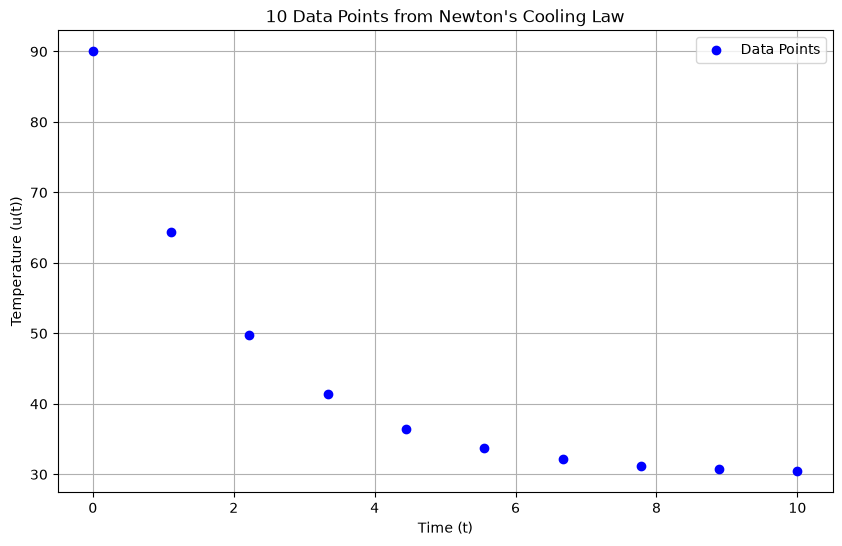

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Constants for Newton's Law of Cooling
T = 30       # Ambient temperature
u0 = 90      # Initial temperature
k = 0.5      # Decay constant

# Exact solution of Newton's Law of Cooling
def exact_solution(t):
    return T + (u0 - T) * np.exp(-k * t)

# Generate 10 data points from the exact solution
t_data = np.linspace(0, 10, 10).reshape(-1, 1)  # 10 points in the interval [0, 10]
u_data = exact_solution(t_data)

# Plot the 10 data points (without the exact solution line)
plt.figure(figsize=(10, 6))
plt.scatter(t_data, u_data, color='b', label="Data Points", zorder=5)
plt.xlabel('Time (t)')
plt.ylabel('Temperature (u(t))')
plt.title("10 Data Points from Newton's Cooling Law")
plt.legend()
plt.grid(True)
plt.show()


We pick just a few data points. The first thing is to use non-linear regression to fit a model through the data points (this is just Statistics!)

To solve Newton's Law of Cooling using polynomial regression with degrees 1, 2, 3, and 4, we'll:

Generate 7 data points from the exact solution of Newton's Law of Cooling.
Fit polynomial regression models with varying degrees (1 to 4).
Plot the exact solution, the data points, and the fitted polynomial regression curves.

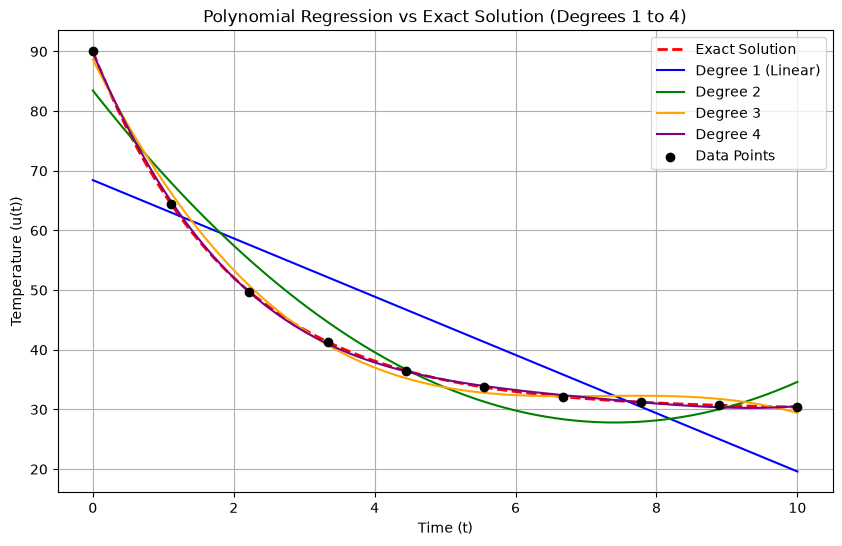

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Constants for Newton's Law of Cooling
T = 30       # Ambient temperature
u0 = 90      # Initial temperature
k = 0.5      # Decay constant

# Exact solution of Newton's Law of Cooling
def exact_solution(t):
    return T + (u0 - T) * np.exp(-k * t)

# Function to perform polynomial regression and predict values
def polynomial_regression(t_data, u_data, degree, t_test):
    poly = PolynomialFeatures(degree)
    t_poly = poly.fit_transform(t_data)

    # Train the model
    model = LinearRegression()
    model.fit(t_poly, u_data)

    # Predict values using the fitted model
    t_test_poly = poly.transform(t_test)
    u_pred = model.predict(t_test_poly)

    return u_pred

# Generate 7 data points from the exact solution
t_data = np.linspace(0, 10, 10).reshape(-1, 1)  # 7 points in the interval [0, 10]
u_data = exact_solution(t_data)

# Generate a range of time values for plotting
t_test = np.linspace(0, 10, 100).reshape(-1, 1)

# Perform polynomial regression for degrees 1, 2, 3, and 4
u_pred_deg1 = polynomial_regression(t_data, u_data, 1, t_test)
u_pred_deg2 = polynomial_regression(t_data, u_data, 2, t_test)
u_pred_deg3 = polynomial_regression(t_data, u_data, 3, t_test)
u_pred_deg4 = polynomial_regression(t_data, u_data, 4, t_test)

# Exact solution for comparison
u_exact = exact_solution(t_test)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(t_test, u_exact, label="Exact Solution", linestyle='dashed', color='r', linewidth=2)
plt.plot(t_test, u_pred_deg1, label="Degree 1 (Linear)", color='b', linestyle='-', linewidth=1.5)
plt.plot(t_test, u_pred_deg2, label="Degree 2", color='g', linestyle='-', linewidth=1.5)
plt.plot(t_test, u_pred_deg3, label="Degree 3", color='orange', linestyle='-', linewidth=1.5)
plt.plot(t_test, u_pred_deg4, label="Degree 4", color='purple', linestyle='-', linewidth=1.5)

# Plot the original data points
plt.scatter(t_data, u_data, color='black', label="Data Points", zorder=5)

# Add labels and title
plt.xlabel('Time (t)')
plt.ylabel('Temperature (u(t))')
plt.title("Polynomial Regression vs Exact Solution (Degrees 1 to 4)")
plt.legend()
plt.grid(True)
plt.show()


**Unsupervised Learning**

We shall use a Physics-Informed Neural Network.
Thus, we set up a neural network that takes time
$t$ as input and outputs
$u(t)$ as the predicted temperature.

The loss function is composed of two parts:

$(i)$ Initial condition loss: Ensures the model satisfies
$u(0)=90$.

$(ii)$ Differential equation loss:
Ensures the model satisfies Newton's Law of cooling

Training: We will train the neural network to minimize the total loss, whcich is the sum of the aforementioned losses.

Plotting: We'll plot the predicted solution from the PINN against the exact solution for comparison reasons.

The first code uses two hiddenlayers with tanh activations and 5000 epochs of training.

Epoch 0, Loss: 24551.564453125
Epoch 500, Loss: 17393.87890625
Epoch 1000, Loss: 13039.1181640625
Epoch 1500, Loss: 9649.9326171875
Epoch 2000, Loss: 6999.125
Epoch 2500, Loss: 4962.927734375
Epoch 3000, Loss: 3266.048583984375
Epoch 3500, Loss: 2016.95849609375
Epoch 4000, Loss: 1153.7061767578125
Epoch 4500, Loss: 596.6626586914062


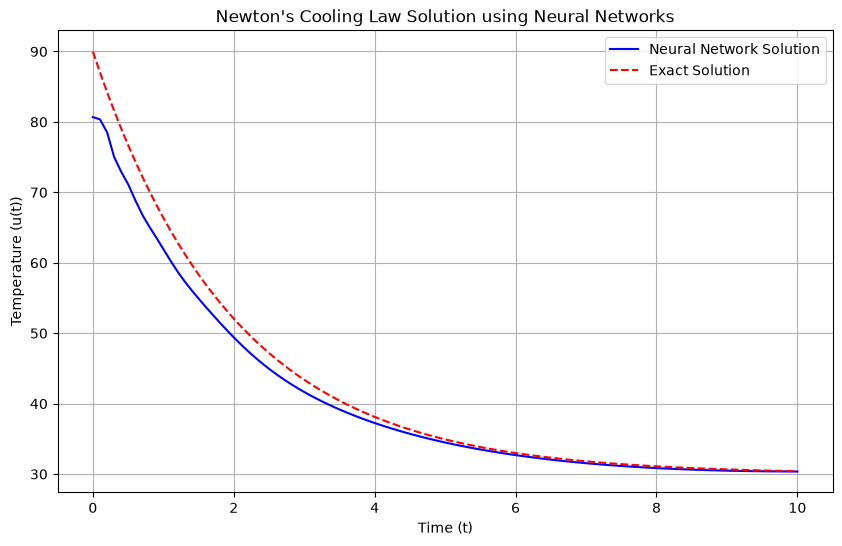

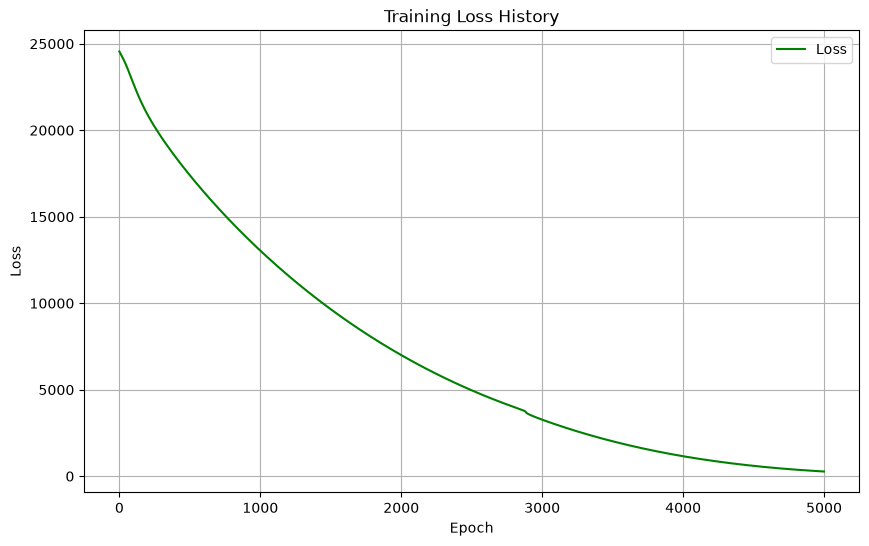

In [3]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Constants for the problem
T = 30       # Ambient temperature
u0 = 90      # Initial temperature
k = 0.5      # Decay constant

# Time domain (converted to PyTorch tensor)
t = np.linspace(0, 10, 100).reshape(-1, 1)
t = torch.tensor(t, dtype=torch.float32, requires_grad=True)  # requires_grad for autograd derivatives

# Build the neural network model
model = nn.Sequential(
    nn.Linear(1, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 1)
)

# Loss function for Newton's Law of Cooling
def cooling_loss(t, model):
    u = model(t)  # Compute the network prediction for u(t)

    # Derivative of u(t) with respect to t (autograd equivalent of GradientTape)
    u_t = torch.autograd.grad(
        outputs=u,
        inputs=t,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    # Newton's cooling equation: u_t + k(u - T) = 0
    pde_loss = torch.mean((u_t + k * (u - T)) ** 2)

    # Boundary condition loss: u(0) = u0
    t0 = torch.tensor([[0.0]], dtype=torch.float32)
    boundary_loss = (model(t0) - u0) ** 2

    # Total loss
    return pde_loss + 3 * boundary_loss

# Custom training loop
optimizer = torch.optim.Adam(model.parameters())

# Training loop
epochs = 5000
loss_history = []
for epoch in range(epochs):
    optimizer.zero_grad()

    loss = cooling_loss(t, model)  # Calculate the loss

    # Compute the gradients and apply optimization
    loss.backward()
    optimizer.step()

    # Record the loss value
    loss_history.append(loss.item())

    # Print progress every 500 epochs
    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

# Predict u(t) for plotting
t_test = np.linspace(0, 10, 100).reshape(-1, 1)
t_test = torch.tensor(t_test, dtype=torch.float32)

with torch.no_grad():  # no gradients needed for inference
    u_pred = model(t_test).numpy()

# Exact solution
u_exact = T + (u0 - T) * np.exp(-k * t_test.numpy())

# Plot the neural network solution and the exact solution
plt.figure(figsize=(10, 6))
plt.plot(t_test.numpy(), u_pred, label="Neural Network Solution", color='b')
plt.plot(t_test.numpy(), u_exact, label="Exact Solution", linestyle='dashed', color='r')
plt.xlabel('Time (t)')
plt.ylabel('Temperature (u(t))')
plt.title("Newton's Cooling Law Solution using Neural Networks")
plt.legend()
plt.grid(True)
plt.show()

# Plot the loss history
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), loss_history, label="Loss", color='g')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss History')
plt.legend()
plt.grid(True)
plt.show()

Next, we shall use an unsupervised learning using PINNs trainned for 10,000 epochs.

Epoch 0, Loss: 24593.53515625
Epoch 500, Loss: 17371.986328125
Epoch 1000, Loss: 13023.712890625
Epoch 1500, Loss: 9637.7421875
Epoch 2000, Loss: 6989.44091796875
Epoch 2500, Loss: 4955.4228515625
Epoch 3000, Loss: 3441.620361328125
Epoch 3500, Loss: 2171.21630859375
Epoch 4000, Loss: 1193.4559326171875
Epoch 4500, Loss: 612.2349853515625
Epoch 5000, Loss: 275.86279296875
Epoch 5500, Loss: 106.67537689208984
Epoch 6000, Loss: 35.0305061340332
Epoch 6500, Loss: 11.489974975585938
Epoch 7000, Loss: 4.039453506469727
Epoch 7500, Loss: 1.261244535446167
Epoch 8000, Loss: 0.3735142946243286
Epoch 8500, Loss: 0.12589164078235626
Epoch 9000, Loss: 0.05048798397183418
Epoch 9500, Loss: 0.023366568610072136


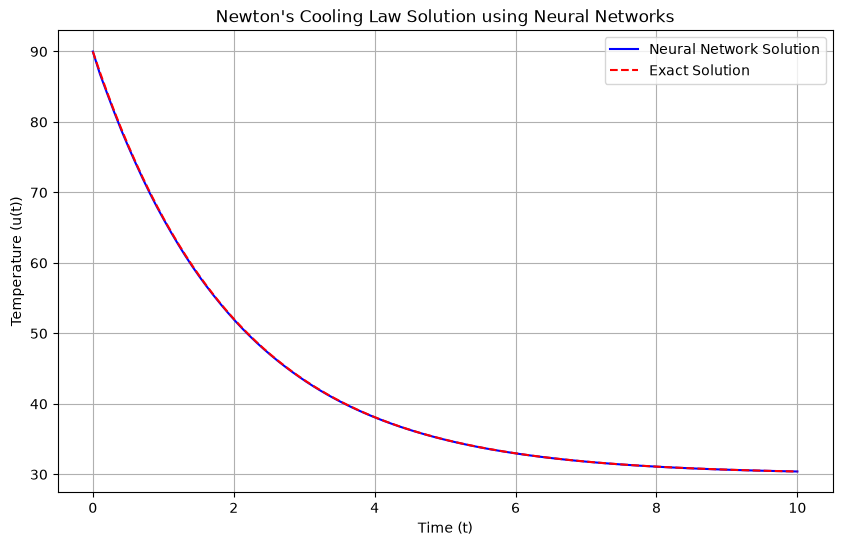

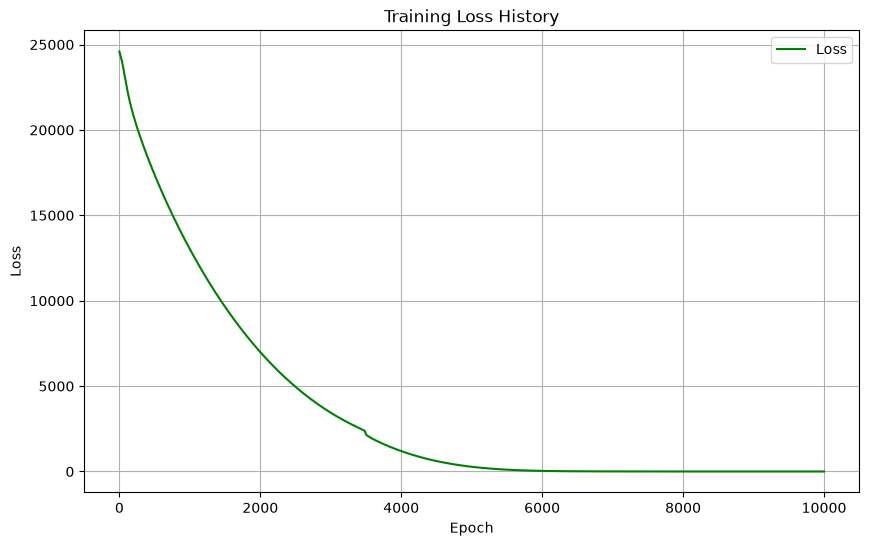

In [4]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Constants for the problem
T = 30       # Ambient temperature
u0 = 90      # Initial temperature
k = 0.5      # Decay constant

# Time domain (converted to PyTorch tensor)
t = np.linspace(0, 10, 100).reshape(-1, 1)
t = torch.tensor(t, dtype=torch.float32, requires_grad=True)  # requires_grad for autograd derivatives

# Build the neural network model
model = nn.Sequential(
    nn.Linear(1, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 1)
)

# Loss function for Newton's Law of Cooling
def cooling_loss(t, model):
    u = model(t)  # Compute the network prediction for u(t)

    # Derivative of u(t) with respect to t (autograd equivalent of GradientTape)
    u_t = torch.autograd.grad(
        outputs=u,
        inputs=t,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    # Newton's cooling equation: u_t + k(u - T) = 0
    pde_loss = torch.mean((u_t + k * (u - T)) ** 2)

    # Boundary condition loss: u(0) = u0
    t0 = torch.tensor([[0.0]], dtype=torch.float32)
    boundary_loss = (model(t0) - u0) ** 2

    # Total loss
    return pde_loss + 3 * boundary_loss

# Custom training loop
optimizer = torch.optim.Adam(model.parameters())

# Training loop
epochs = 10000
loss_history = []
for epoch in range(epochs):
    optimizer.zero_grad()

    loss = cooling_loss(t, model)  # Calculate the loss

    # Compute the gradients and apply optimization
    loss.backward()
    optimizer.step()

    # Record the loss value
    loss_history.append(loss.item())

    # Print progress every 500 epochs
    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

# Predict u(t) for plotting
t_test = np.linspace(0, 10, 100).reshape(-1, 1)
t_test = torch.tensor(t_test, dtype=torch.float32)

with torch.no_grad():  # no gradients needed for inference
    u_pred = model(t_test).numpy()

# Exact solution
u_exact = T + (u0 - T) * np.exp(-k * t_test.numpy())

# Plot the neural network solution and the exact solution
plt.figure(figsize=(10, 6))
plt.plot(t_test.numpy(), u_pred, label="Neural Network Solution", color='b')
plt.plot(t_test.numpy(), u_exact, label="Exact Solution", linestyle='dashed', color='r')
plt.xlabel('Time (t)')
plt.ylabel('Temperature (u(t))')
plt.title("Newton's Cooling Law Solution using Neural Networks")
plt.legend()
plt.grid(True)
plt.show()

# Plot the loss history
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), loss_history, label="Loss", color='g')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss History')
plt.legend()
plt.grid(True)
plt.show()

This is a perfect match. This "unsupervised" learning provides the exact solution. But it takes far too long to learn the solution...
Can we do it faster? Maybe using some data points obtained from measurements
of the coffee temperature?

Note that we changed the activation function to ReLu to avoid vanishing gradients.



**Supervised Learning: Neural Network Interpolation of Data**

The next code builds a neural network to learn the temperature from 10 given measurements. It has two hidden layers, 40 neurons each, and it is trained for 2000 epochs. The results are not a perfect match. Why? Because information is missing between the measurements!

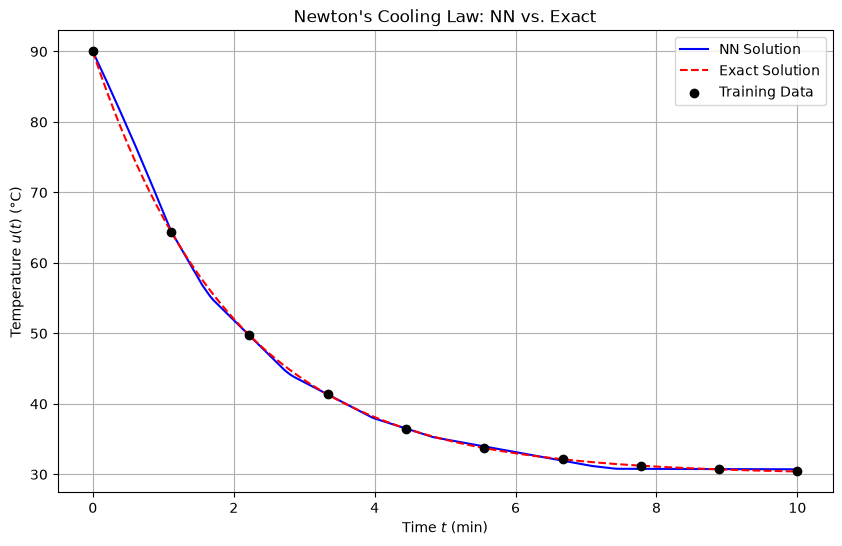

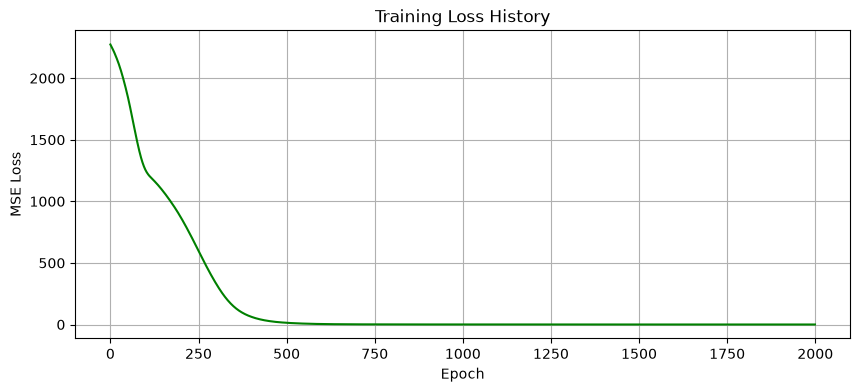

In [6]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# --- 1) Problem setup --------------------------------------------------------

# Newton’s law constants
T_env = 30.0        # ambient temperature
u0    = 90.0        # initial temperature
k     = 0.5         # decay constant

# Exact solution for comparison
def exact_solution(t):
    return T_env + (u0 - T_env) * np.exp(-k * t)

# Data points (t, u) to enforce
t_data = np.linspace(0, 10, 10).reshape(-1, 1).astype(np.float32)
u_data = exact_solution(t_data).astype(np.float32)

t_data_tensor = torch.from_numpy(t_data)
u_data_tensor = torch.from_numpy(u_data)

dataset = TensorDataset(t_data_tensor, u_data_tensor)
loader = DataLoader(dataset, batch_size=10, shuffle=True)

# --- 2) Build the network ---------------------------------------------------

model = nn.Sequential(
    nn.Linear(1, 40),
    nn.ReLU(),
    nn.Linear(40, 40),
    nn.ReLU(),
    nn.Linear(40, 1)
)

# --- 3) Compile with loss = MSE on the known points ------

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters())

# --- 4) Train only on the data points ---------------------------------------

loss_history = []

for epoch in range(2000):
    epoch_loss = 0.0
    for t_batch, u_batch in loader:
        optimizer.zero_grad()
        u_pred_batch = model(t_batch)
        loss = criterion(u_pred_batch, u_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * t_batch.size(0)
    epoch_loss /= len(dataset)
    loss_history.append(epoch_loss)

# --- 5) Evaluate & plot -----------------------------------------------------

# A fine grid for plotting
t_plot = np.linspace(0, 10, 200).reshape(-1, 1).astype(np.float32)
t_plot_tensor = torch.from_numpy(t_plot)

model.eval()
with torch.no_grad():
    u_pred = model(t_plot_tensor).numpy()

u_exact = exact_solution(t_plot)

plt.figure(figsize=(10,6))
plt.plot(t_plot, u_pred,  label="NN Solution", color='b')
plt.plot(t_plot, u_exact, label="Exact Solution", linestyle='--', color='r')
plt.scatter(t_data, u_data, color='k', label="Training Data", zorder=5)
plt.xlabel('Time $t$ (min)')
plt.ylabel('Temperature $u(t)$ (°C)')
plt.title("Newton's Cooling Law: NN vs. Exact")
plt.legend()
plt.grid(True)
plt.show()

# Plot training loss
plt.figure(figsize=(10,4))
plt.plot(loss_history, color='g')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss History')
plt.grid(True)
plt.show()

**Comparison of Loss function evolution**

The next code provides the loss function for three architectures: Arch #1: one layer with 20 neurons, Arch#2 with 2 layers, 40-20 neurons, and Arch#3 with three layers 80-40-20 neurons.


Training architecture #1 ...

Training architecture #2 ...

Training architecture #3 ...


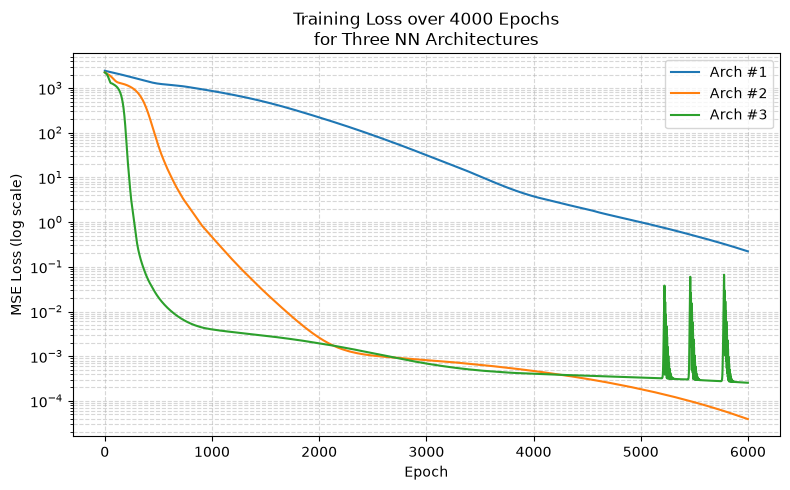

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# --- 1) Prepare the data ----------------------------------------------------
T_env = 30.0
u0    = 90.0
k     = 0.5

def exact_solution(t):
    return T_env + (u0 - T_env) * np.exp(-k * t)

# Ten sample points
t_data = np.linspace(0, 10, 10).reshape(-1,1).astype(np.float32)
u_data = exact_solution(t_data).astype(np.float32)

t_tensor = torch.from_numpy(t_data)
u_tensor = torch.from_numpy(u_data)

# --- 2) Define three architectures -----------------------------------------

def make_model(arch_id):
    if arch_id == 1:
        layers = [nn.Linear(1, 20), nn.ReLU()]
        last_dim = 20
    elif arch_id == 2:
        layers = [nn.Linear(1, 40), nn.ReLU(),
                  nn.Linear(40, 20), nn.ReLU()]
        last_dim = 20
    else:  # arch_id == 3
        layers = [nn.Linear(1, 80), nn.ReLU(),
                  nn.Linear(80, 40), nn.ReLU(),
                  nn.Linear(40, 20), nn.ReLU()]
        last_dim = 20
    layers.append(nn.Linear(last_dim, 1))
    return nn.Sequential(*layers)

# --- 3) Train all three, record loss histories ------------------------------

histories = {}
epochs = 6000
batch_size = 10  # equals dataset size, so it's full-batch training each epoch

dataset = torch.utils.data.TensorDataset(t_tensor, u_tensor)

for arch in [1, 2, 3]:
    model = make_model(arch)
    optimizer = torch.optim.Adam(model.parameters())
    criterion = nn.MSELoss()
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    print(f"\nTraining architecture #{arch} ...")
    loss_hist = []
    for epoch in range(epochs):
        epoch_losses = []
        for t_batch, u_batch in loader:
            optimizer.zero_grad()
            pred = model(t_batch)
            loss = criterion(pred, u_batch)
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())
        loss_hist.append(np.mean(epoch_losses))

    histories[arch] = loss_hist

# --- 4) Plot all three loss curves ------------------------------------------

plt.figure(figsize=(8,5))
for arch, loss_hist in histories.items():
    plt.plot(loss_hist, label=f"Arch #{arch}")
plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (log scale)")
plt.title("Training Loss over 4000 Epochs\nfor Three NN Architectures")
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Hybrid Approach**

Next we consider a hybrid approach. This means that besides data measurements we also use the PINN approach, which fills the info in between measurements.

Epoch 0, Loss: 9902.62890625
Epoch 500, Loss: 2.995701551437378
Epoch 1000, Loss: 1.6808639764785767
Epoch 1500, Loss: 0.9412385821342468
Epoch 2000, Loss: 0.9002069234848022
Epoch 2500, Loss: 0.8706966042518616
Epoch 3000, Loss: 0.9314375519752502
Epoch 3500, Loss: 0.8813219666481018
Epoch 4000, Loss: 0.9367629289627075
Epoch 4500, Loss: 0.6155803203582764
Epoch 5000, Loss: 0.7359387874603271
Epoch 5500, Loss: 0.5846114158630371


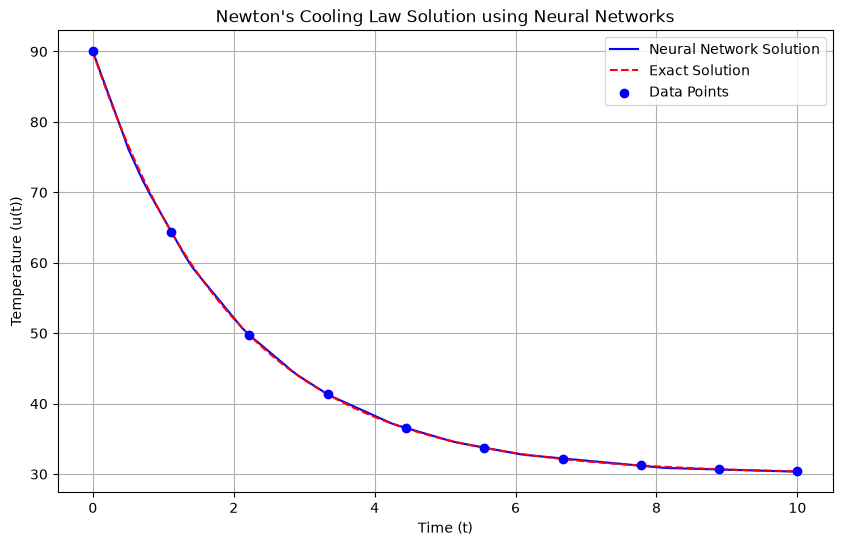

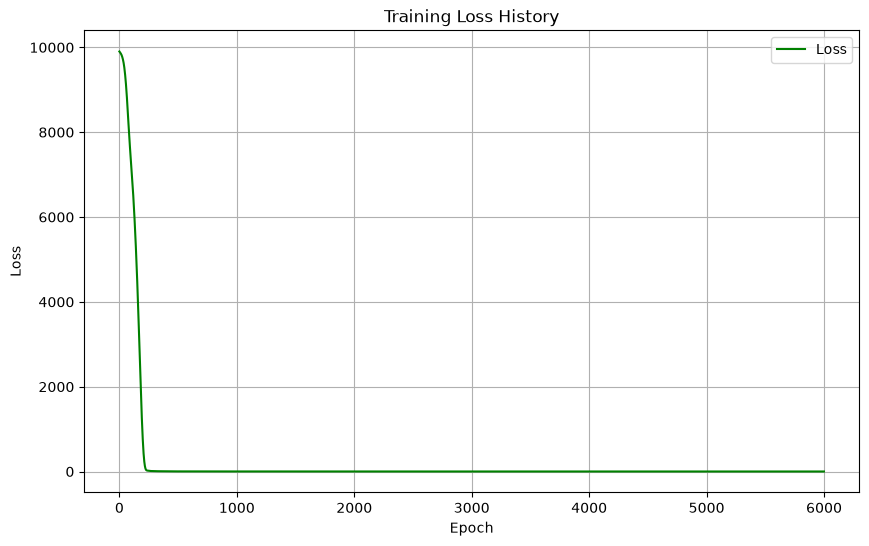

In [8]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Constants for the problem
T = 30       # Ambient temperature
u0 = 90     # Initial temperature
k = 0.5      # Decay constant

# Exact solution of Newton's Law of Cooling
def exact_solution(t):
    return T + (u0 - T) * np.exp(-k * t)

# Time domain (converted to PyTorch tensor)
t = np.linspace(0, 10, 100).reshape(-1, 1)
t = torch.tensor(t, dtype=torch.float32, requires_grad=True)  # Convert t to PyTorch tensor (requires_grad for autograd)

# Build the neural network model
model = nn.Sequential(
    nn.Linear(1, 40),
    nn.ReLU(),
    nn.Linear(40, 30),
    nn.ReLU(),
    nn.Linear(30, 20),
    nn.ReLU(),
    nn.Linear(20, 1)
)

# Loss function for Newton's Law of Cooling
def cooling_loss(t):
    u = model(t)  # Compute the network prediction for u(t)

    # Derivative of u(t) with respect to t (via autograd)
    u_t = torch.autograd.grad(
        outputs=u,
        inputs=t,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    # Newton's cooling equation: u_t + k(u - T) = 0
    pde_loss = torch.mean((u_t + k * (u - T)) ** 2)

    # Boundary condition loss: u(0) = u0
    t_zero = torch.tensor([[0.0]], dtype=torch.float32)
    boundary_loss1 = torch.square(model(t_zero) - u0)

    # Boundary condition loss: u(0) = u0 and additional boundary points
    boundary_times = torch.tensor(
        [[0.0], [1.11], [2.22], [3.33], [4.44], [5.56], [6.67], [7.78], [8.89], [10.00]],
        dtype=torch.float32
    )
    boundary_values = u0 * torch.exp(-k * boundary_times) + T * (1 - torch.exp(-k * boundary_times))
    boundary_loss = torch.mean((model(boundary_times) - boundary_values) ** 2)

    # Total loss
    return pde_loss + 1 * boundary_loss1.squeeze() + 0.7 * boundary_loss

# Custom training loop
optimizer = torch.optim.Adam(model.parameters())

# Training loop
epochs = 6000
loss_history = []
for epoch in range(epochs):
    optimizer.zero_grad()
    loss = cooling_loss(t)  # Calculate the loss

    # Compute the gradients and apply optimization
    loss.backward()
    optimizer.step()

    # Record the loss value
    loss_history.append(loss.item())

    # Print progress every 500 epochs
    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

# Predict u(t) for plotting
t_test = np.linspace(0, 10, 100).reshape(-1, 1)
t_test = torch.tensor(t_test, dtype=torch.float32)  # Convert t_test to PyTorch tensor

with torch.no_grad():
    u_pred = model(t_test).numpy()

# Exact solution
u_exact = T + (u0 - T) * np.exp(-k * t_test.numpy())

# Data points
t_data = np.linspace(0, 10, 10).reshape(-1, 1)
u_data = exact_solution(t_data)

# Plot the neural network solution and the exact solution
plt.figure(figsize=(10, 6))
plt.plot(t_test.numpy(), u_pred, label="Neural Network Solution", color='b')
plt.plot(t_test.numpy(), u_exact, label="Exact Solution", linestyle='dashed', color='r')
plt.scatter(t_data, u_data, color='b', label="Data Points", zorder=5)
plt.xlabel('Time (t)')
plt.ylabel('Temperature (u(t))')
plt.title("Newton's Cooling Law Solution using Neural Networks")
plt.legend()
plt.grid(True)
plt.show()

# Plot the loss history
# (loss_history already contains plain floats from .item())
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), loss_history, label="Loss", color='g')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss History')
plt.legend()
plt.grid(True)
plt.show()

**An improved variant of learning**

We modify the code by looking for a solution of the form:
$$
u(t)=u(0)+t⋅NN(θ,t).
$$
We introduce this form explicitly into the model. The neural network

$NN(θ,t)$ represents the correction term, and the boundary condition
$
u(0)=u_0$
is automatically satisfied. Here's the modified code:

Epoch 0, Loss: 1010.1261596679688


Epoch 500, Loss: 135.14971923828125
Epoch 1000, Loss: 110.73251342773438
Epoch 1500, Loss: 33.61880874633789
Epoch 2000, Loss: 16.584884643554688
Epoch 2500, Loss: 9.519603729248047
Epoch 3000, Loss: 5.793612480163574
Epoch 3500, Loss: 3.6522955894470215
Epoch 4000, Loss: 2.29502272605896
Epoch 4500, Loss: 1.426979660987854


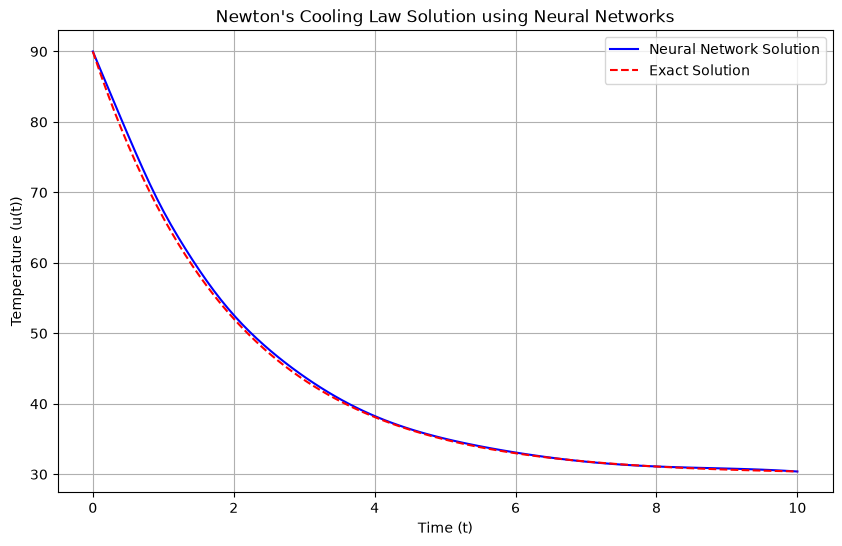

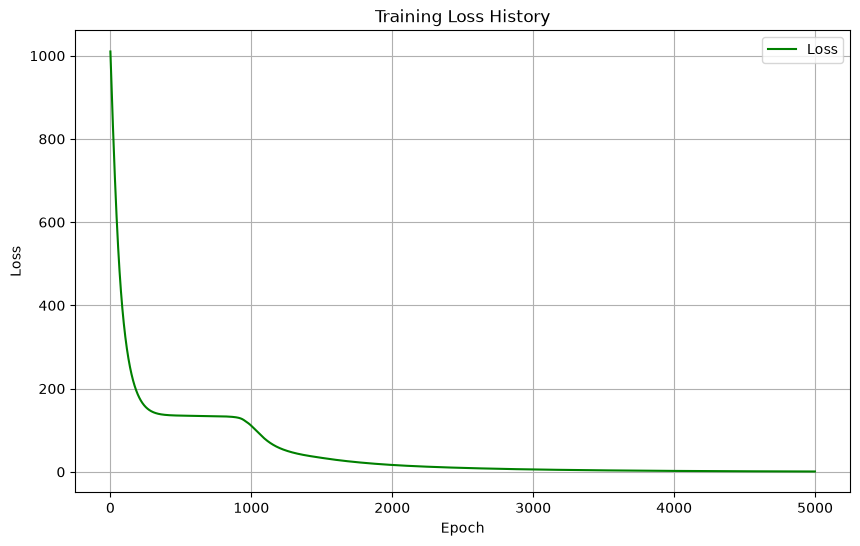

In [9]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Constants for the problem
T = 30       # Surrounding temperature
u0 = 90      # Initial temperature
k = 0.5      # Cooling constant

# Time domain (converted to PyTorch tensor)
t = np.linspace(0, 10, 100).reshape(-1, 1)
t = torch.tensor(t, dtype=torch.float32, requires_grad=True)  # Convert t to PyTorch tensor

# Build the neural network model
model = nn.Sequential(
    nn.Linear(1, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 1)
)

# Define the custom solution form: u(t) = u0 + t * NN(t)
def solution(t):
    nn_output = model(t)
    return u0 + t * nn_output

# Loss function for Newton's Law of Cooling
def cooling_loss(t):
    u = solution(t)  # Compute the solution u(t) using the custom form
    u_t = torch.autograd.grad(
        u, t, grad_outputs=torch.ones_like(u), create_graph=True
    )[0]  # Derivative of u(t) with respect to t

    # Newton's cooling equation: u_t + k(u - T) = 0
    pde_loss = torch.mean((u_t + k * (u - T)) ** 2)

    # Total loss
    return pde_loss

# Custom training loop
optimizer = torch.optim.Adam(model.parameters())

# Training loop
epochs = 5000
loss_history = []
for epoch in range(epochs):
    optimizer.zero_grad()
    loss = cooling_loss(t)  # Calculate the loss

    # Compute the gradients and apply optimization
    loss.backward()
    optimizer.step()

    # Record the loss value
    loss_history.append(loss.item())

    # Print progress every 500 epochs
    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

# Predict u(t) for plotting
t_test = np.linspace(0, 10, 100).reshape(-1, 1)
t_test = torch.tensor(t_test, dtype=torch.float32, requires_grad=True)  # Convert t_test to PyTorch tensor
u_pred = solution(t_test).detach().numpy()  # Compute u(t) using the trained neural network

# Exact solution
u_exact = T + (u0 - T) * np.exp(-k * t_test.detach().numpy())

# Plot the neural network solution and the exact solution
plt.figure(figsize=(10, 6))
plt.plot(t_test.detach().numpy(), u_pred, label="Neural Network Solution", color='b')
plt.plot(t_test.detach().numpy(), u_exact, label="Exact Solution", linestyle='dashed', color='r')
plt.xlabel('Time (t)')
plt.ylabel('Temperature (u(t))')
plt.title("Newton's Cooling Law Solution using Neural Networks")
plt.legend()
plt.grid(True)
plt.show()

# Plot the loss history
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), loss_history, label="Loss", color='g')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss History')
plt.legend()
plt.grid(True)
plt.show()


**Hybrid approach**

Epoch 0, Loss: 5082.78662109375
Epoch 500, Loss: 530.032470703125
Epoch 1000, Loss: 529.8665771484375
Epoch 1500, Loss: 105.1927490234375
Epoch 2000, Loss: 8.128876686096191
Epoch 2500, Loss: 3.178107738494873
Epoch 3000, Loss: 1.6415296792984009
Epoch 3500, Loss: 0.8812508583068848
Epoch 4000, Loss: 0.48811203241348267
Epoch 4500, Loss: 0.27893438935279846


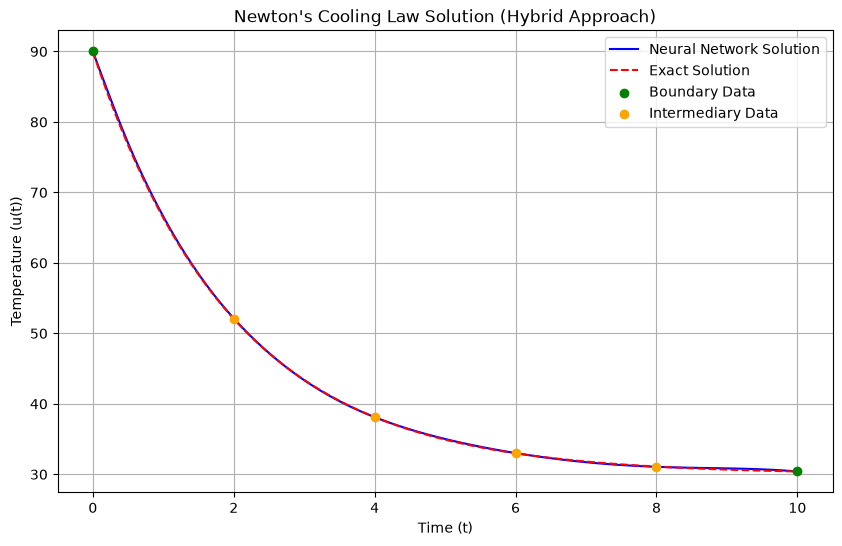

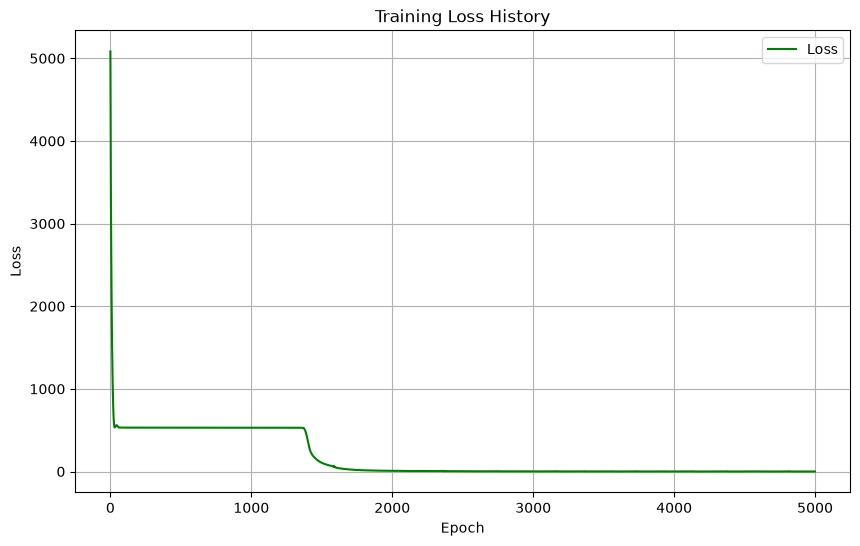

In [12]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Constants for the problem
T = 30       # Surrounding temperature
u0 = 90      # Initial temperature
k = 0.5      # Cooling constant

# Time domain for training
t = np.linspace(0, 10, 100).reshape(-1, 1)  # 100 time points for training

# Boundary data points
t_boundary = np.array([[0.0], [10.0]])  # Initial and final time
u_boundary = np.array([[u0], [T + (u0 - T) * np.exp(-k * 10)]])

# Intermediary data points (4 points)
t_intermediary = np.array([[2.0], [4.0], [6.0], [8.0]])
u_intermediary = T + (u0 - T) * np.exp(-k * t_intermediary)  # Analytical solution for intermediary points

# Convert to PyTorch tensors
# t needs requires_grad=True so we can take d(u)/d(t) via autograd
t_boundary = torch.tensor(t_boundary, dtype=torch.float32)
u_boundary = torch.tensor(u_boundary, dtype=torch.float32)
t_intermediary = torch.tensor(t_intermediary, dtype=torch.float32)
u_intermediary = torch.tensor(u_intermediary, dtype=torch.float32)
t = torch.tensor(t, dtype=torch.float32, requires_grad=True)

# Build the neural network model
model = nn.Sequential(
    nn.Linear(1, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 1)
)

# Define the custom solution form: u(t) = u0 + t * NN(t)
def solution(t):
    nn_output = model(t)
    return u0 + t * nn_output

# Loss function
def hybrid_loss(t, t_boundary, u_boundary, t_intermediary, u_intermediary):
    # Physics-Informed Loss (PDE)
    u = solution(t)  # Compute the solution u(t)
    # Derivative of u(t) with respect to t via autograd (equivalent to tf.GradientTape)
    u_t = torch.autograd.grad(
        outputs=u,
        inputs=t,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]
    pde_loss = torch.mean((u_t + k * (u - T)) ** 2)

    # Boundary Loss (Supervised at t_boundary)
    u_pred_boundary = solution(t_boundary)
    boundary_loss = torch.mean((u_pred_boundary - u_boundary) ** 2)

    # Intermediary Loss (Supervised at intermediary points)
    u_pred_intermediary = solution(t_intermediary)
    intermediary_loss = torch.mean((u_pred_intermediary - u_intermediary) ** 2)

    # Total Loss
    return pde_loss + boundary_loss + intermediary_loss

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training loop
epochs = 5000
loss_history = []
for epoch in range(epochs):
    optimizer.zero_grad()  # Clear previous gradients (equivalent to a fresh GradientTape)

    loss = hybrid_loss(t, t_boundary, u_boundary, t_intermediary, u_intermediary)  # Calculate the loss

    # Compute the gradients and apply optimization
    loss.backward()
    optimizer.step()

    # Record the loss value
    loss_history.append(loss.item())

    # Print progress every 500 epochs
    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

# Predict u(t) for plotting
t_test = np.linspace(0, 10, 100).reshape(-1, 1)
t_test = torch.tensor(t_test, dtype=torch.float32)  # Convert t_test to PyTorch tensor
with torch.no_grad():
    u_pred = solution(t_test).numpy()  # Compute u(t) using the trained neural network

# Exact solution
u_exact = T + (u0 - T) * np.exp(-k * t_test.numpy())

# Plot the neural network solution and the exact solution
plt.figure(figsize=(10, 6))
plt.plot(t_test.numpy(), u_pred, label="Neural Network Solution", color='b')
plt.plot(t_test.numpy(), u_exact, label="Exact Solution", linestyle='dashed', color='r')
plt.scatter(t_boundary.detach().numpy(), u_boundary.numpy(), color='g', label="Boundary Data", zorder=5)
plt.scatter(t_intermediary.numpy(), u_intermediary.numpy(), color='orange', label="Intermediary Data", zorder=5)
plt.xlabel('Time (t)')
plt.ylabel('Temperature (u(t))')
plt.title("Newton's Cooling Law Solution (Hybrid Approach)")
plt.legend()
plt.grid(True)
plt.show()

# Plot the loss history
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), loss_history, label="Loss", color='g')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss History')
plt.legend()
plt.grid(True)
plt.show()

Epoch 0, Loss: 5120.326171875
Epoch 500, Loss: 529.9677124023438
Epoch 1000, Loss: 165.2974853515625
Epoch 1500, Loss: 9.078076362609863
Epoch 2000, Loss: 3.666490316390991
Epoch 2500, Loss: 1.9825825691223145
Epoch 3000, Loss: 1.1203521490097046
Epoch 3500, Loss: 0.6527551412582397
Epoch 4000, Loss: 0.3967841565608978
Epoch 4500, Loss: 0.24425046145915985
After L-BFGS, Loss: 5.172591772861779e-05


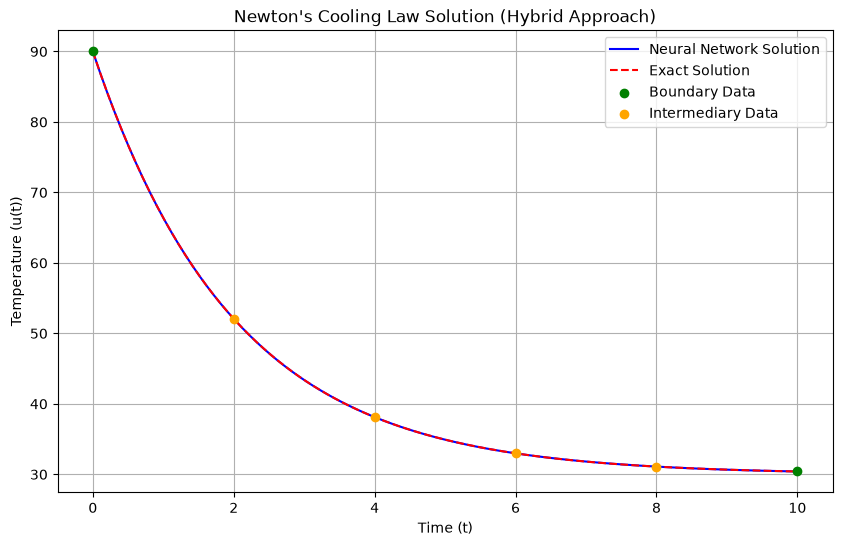

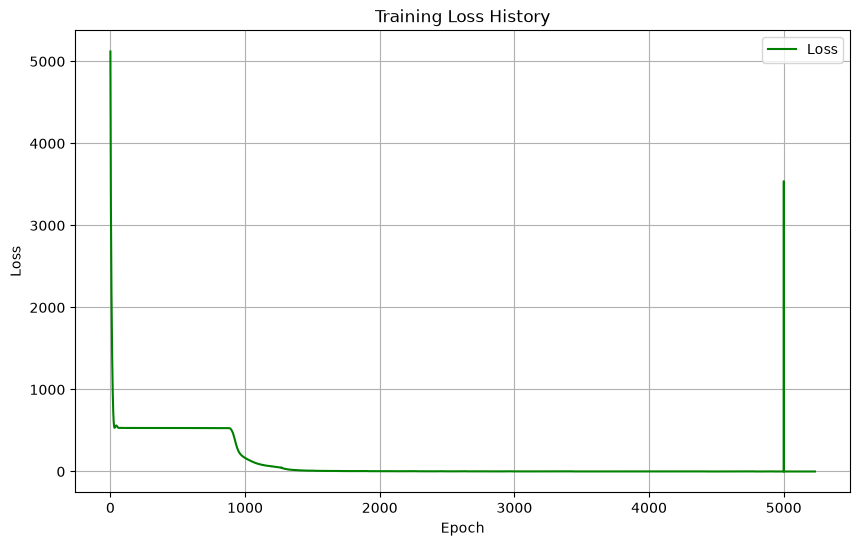

In [13]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Constants for the problem
T = 30       # Surrounding temperature
u0 = 90      # Initial temperature
k = 0.5      # Cooling constant

# Time domain for training
t = np.linspace(0, 10, 100).reshape(-1, 1)  # 100 time points for training

# Boundary data points
t_boundary = np.array([[0.0], [10.0]])  # Initial and final time
u_boundary = np.array([[u0], [T + (u0 - T) * np.exp(-k * 10)]])

# Intermediary data points (4 points)
t_intermediary = np.array([[2.0], [4.0], [6.0], [8.0]])
u_intermediary = T + (u0 - T) * np.exp(-k * t_intermediary)  # Analytical solution for intermediary points

# Convert to PyTorch tensors
# t needs requires_grad=True so we can take d(u)/d(t) via autograd
t_boundary = torch.tensor(t_boundary, dtype=torch.float32)
u_boundary = torch.tensor(u_boundary, dtype=torch.float32)
t_intermediary = torch.tensor(t_intermediary, dtype=torch.float32)
u_intermediary = torch.tensor(u_intermediary, dtype=torch.float32)
t = torch.tensor(t, dtype=torch.float32, requires_grad=True)

# Fix the random seed: without it, initialization is random each run and can
# land in a deep local minimum (loss stuck ~529) that not even L-BFGS escapes.
torch.manual_seed(0)

# Build the neural network model
model = nn.Sequential(
    nn.Linear(1, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 1)
)

# Define the custom solution form: u(t) = u0 + t * NN(t)
def solution(t):
    nn_output = model(t)
    return u0 + t * nn_output

# Loss function
def hybrid_loss(t, t_boundary, u_boundary, t_intermediary, u_intermediary):
    # Physics-Informed Loss (PDE)
    u = solution(t)  # Compute the solution u(t)
    # Derivative of u(t) with respect to t via autograd (equivalent to tf.GradientTape)
    u_t = torch.autograd.grad(
        outputs=u,
        inputs=t,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]
    pde_loss = torch.mean((u_t + k * (u - T)) ** 2)

    # Boundary Loss (Supervised at t_boundary)
    u_pred_boundary = solution(t_boundary)
    boundary_loss = torch.mean((u_pred_boundary - u_boundary) ** 2)

    # Intermediary Loss (Supervised at intermediary points)
    u_pred_intermediary = solution(t_intermediary)
    intermediary_loss = torch.mean((u_pred_intermediary - u_intermediary) ** 2)

    # Total Loss
    return pde_loss + boundary_loss + intermediary_loss

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training loop
epochs = 5000
loss_history = []
for epoch in range(epochs):
    optimizer.zero_grad()  # Clear previous gradients (equivalent to a fresh GradientTape)

    loss = hybrid_loss(t, t_boundary, u_boundary, t_intermediary, u_intermediary)  # Calculate the loss

    # Compute the gradients and apply optimization
    loss.backward()
    optimizer.step()

    # Record the loss value
    loss_history.append(loss.item())

    # Print progress every 500 epochs
    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

# Fine-tuning with L-BFGS: Adam alone can get stuck around loss~529 in a
# straight-line local minimum; a short L-BFGS phase usually escapes it.
lbfgs = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=200, line_search_fn='strong_wolfe')

def closure():
    lbfgs.zero_grad()
    loss = hybrid_loss(t, t_boundary, u_boundary, t_intermediary, u_intermediary)
    loss.backward()
    loss_history.append(loss.item())
    return loss

lbfgs.step(closure)
print(f"After L-BFGS, Loss: {loss_history[-1]}")

# Predict u(t) for plotting
t_test = np.linspace(0, 10, 100).reshape(-1, 1)
t_test = torch.tensor(t_test, dtype=torch.float32)  # Convert t_test to PyTorch tensor
with torch.no_grad():
    u_pred = solution(t_test).numpy()  # Compute u(t) using the trained neural network

# Exact solution
u_exact = T + (u0 - T) * np.exp(-k * t_test.numpy())

# Plot the neural network solution and the exact solution
plt.figure(figsize=(10, 6))
plt.plot(t_test.numpy(), u_pred, label="Neural Network Solution", color='b')
plt.plot(t_test.numpy(), u_exact, label="Exact Solution", linestyle='dashed', color='r')
plt.scatter(t_boundary.detach().numpy(), u_boundary.numpy(), color='g', label="Boundary Data", zorder=5)
plt.scatter(t_intermediary.numpy(), u_intermediary.numpy(), color='orange', label="Intermediary Data", zorder=5)
plt.xlabel('Time (t)')
plt.ylabel('Temperature (u(t))')
plt.title("Newton's Cooling Law Solution (Hybrid Approach)")
plt.legend()
plt.grid(True)
plt.show()

# Plot the loss history
plt.figure(figsize=(10, 6))
plt.plot(range(len(loss_history)), loss_history, label="Loss", color='g')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss History')
plt.legend()
plt.grid(True)
plt.show()